Correlation Matrix:
             ssc_p     hsc_p  degree_p   etest_p     mba_p    salary
ssc_p     1.000000  0.511472  0.538404  0.261993  0.388478  0.108669
hsc_p     0.511472  1.000000  0.434206  0.245113  0.354823  0.122921
degree_p  0.538404  0.434206  1.000000  0.224470  0.402364  0.053352
etest_p   0.261993  0.245113  0.224470  1.000000  0.218055  0.169233
mba_p     0.388478  0.354823  0.402364  0.218055  1.000000  0.155673
salary    0.108669  0.122921  0.053352  0.169233  0.155673  1.000000
Quantitative columns: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

VIF Table:
  variables         VIF
0     ssc_p   66.968237
1     hsc_p   56.268303
2  degree_p  112.717328
3   etest_p   33.511435
4     mba_p  104.464763
5    salary   14.432677


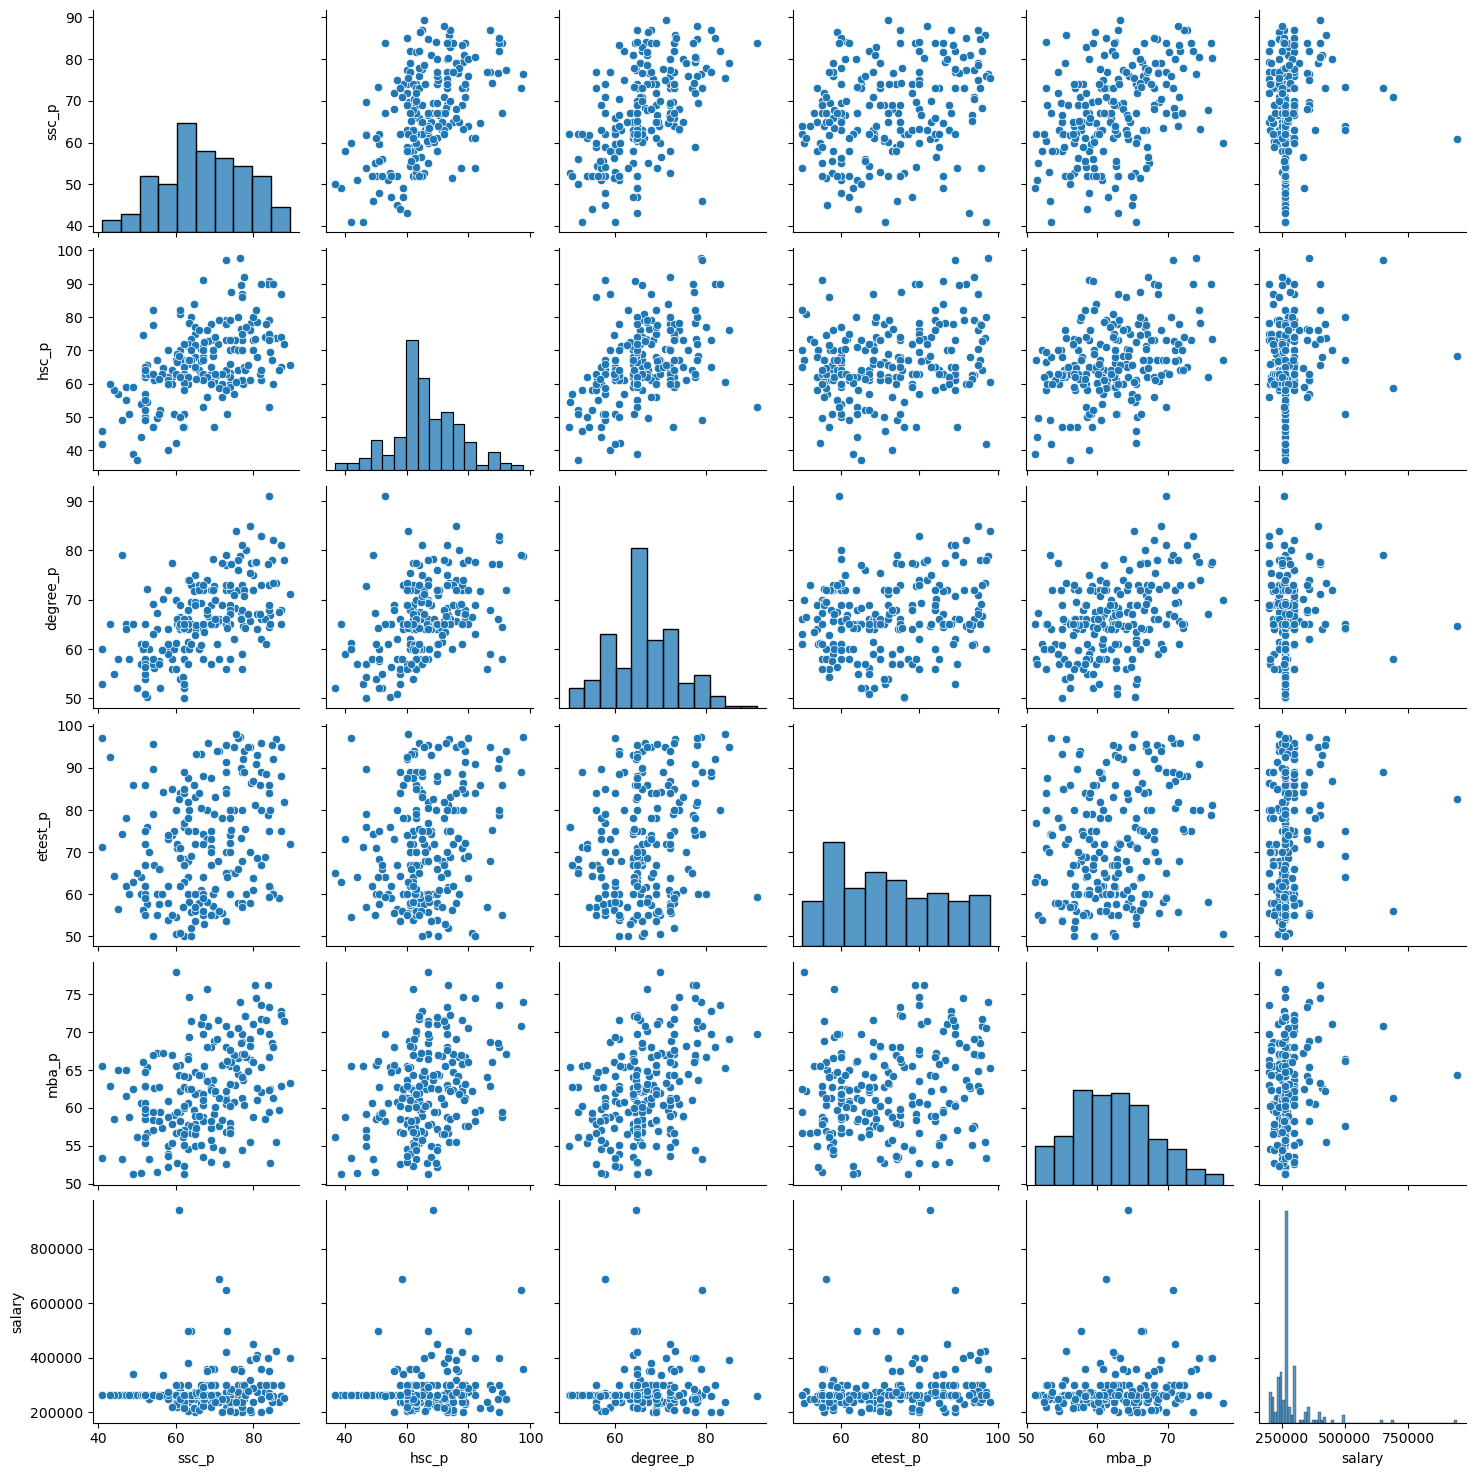

In [37]:
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from Univariate import Univariate

# Load dataset
dataset = pd.read_csv("PreProcess.csv")


# Drop 'sl_no' if it exists
if 'sl_no' in dataset.columns:
    dataset.drop("sl_no", axis=1, inplace=True)
else:
    print("Column 'sl_no' not found in the dataset")

    
# Get quantitative and qualitative columns
quan, qual = Univariate.quanQual(dataset)

# Correlation matrix for quantitative columns
print("Correlation Matrix:")
print(dataset[quan].corr())

# Pairplot
sns.pairplot(dataset)

# Display quantitative columns
print("Quantitative columns:", quan)

# VIF Calculation
def cal_vif(data):
    vif = pd.DataFrame()
    vif["variables"] = data.columns
    vif["VIF"] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    return vif

print("\nVIF Table:")
print(cal_vif(dataset[quan]))

In [42]:
from statsmodels.tools import add_constant

def reduce_vif(data, thresh=5.0):
    variables = list(data.columns)
    dropped = True
    iteration = 1

    while dropped:
        dropped = False

        if len(variables) < 2:
            print("Stopped: fewer than 2 variables remaining.")
            break

        # Add constant to stabilize VIF calculation
        data_with_const = add_constant(data[variables])

        vif = pd.DataFrame()
        vif["variables"] = variables
        vif["VIF"] = [
            variance_inflation_factor(data_with_const.values, i + 1)  # +1 to skip constant
            for i in range(len(variables))
        ]

        print(f"\n--- Iteration {iteration} ---")
        print(vif.sort_values("VIF", ascending=False).to_string(index=False))

        max_vif = vif["VIF"].max()
        if max_vif > thresh:
            drop_var = vif.loc[vif["VIF"].idxmax(), "variables"]
            print(f"✗ Dropping '{drop_var}' (VIF = {max_vif:.2f} > {thresh})")
            variables.remove(drop_var)
            dropped = True
            iteration += 1
        else:
            print(f"\n✓ All VIF values below {thresh}. Done.")

    print("\n========== FINAL RESULT ==========")
    print(f"Retained variables : {variables}")
    print("\nFinal VIF Table:")
    print(vif.sort_values("VIF", ascending=False).to_string(index=False))
    return data[variables]

reduced_data = reduce_vif(dataset[quan])


--- Iteration 1 ---
variables      VIF
    ssc_p 1.686686
 degree_p 1.560630
    hsc_p 1.474472
    mba_p 1.311147
  etest_p 1.128550
   salary 1.051359

✓ All VIF values below 5.0. Done.

========== FINAL RESULT ==========
Retained variables : ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

Final VIF Table:
variables      VIF
    ssc_p 1.686686
 degree_p 1.560630
    hsc_p 1.474472
    mba_p 1.311147
  etest_p 1.128550
   salary 1.051359


In [43]:
dataset

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed,67.00,91.00,58.00,55.0,58.80,270000.0
1,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed,79.33,78.33,77.48,86.5,66.28,200000.0
2,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed,65.00,68.00,64.00,75.0,57.80,250000.0
3,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed,56.00,52.00,52.00,66.0,59.43,265000.0
4,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed,85.80,73.60,73.30,96.8,55.50,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed,80.60,82.00,77.60,91.0,74.49,400000.0
211,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed,58.00,60.00,72.00,74.0,53.62,275000.0
212,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed,67.00,67.00,73.00,59.0,69.72,295000.0
213,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed,74.00,66.00,58.00,70.0,60.23,204000.0
